**Dwonloading the Libraries**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc


**Loading the Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving heart.csv to heart.csv


In [ ]:
df = pd.read_csv('heart.csv')

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


**CoubtPlot**

<Axes: xlabel='target', ylabel='count'>

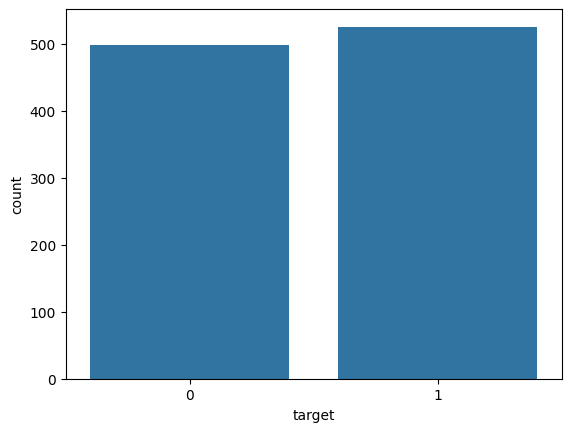

In [ ]:
(sns.countplot(x='target' , data=df))

**Heatmap**

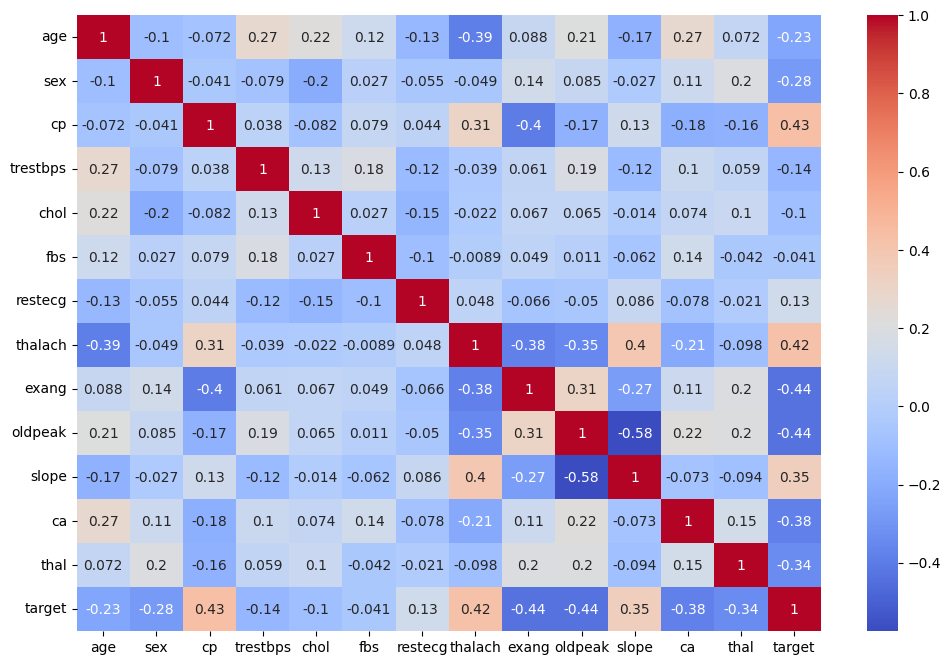

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()


**Train & Test**

In [ ]:
X = df.drop('target', axis=1)
Y = df['target']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train , Y_train)
Y_pred = model.predict(X_test)

**Confusion Matrix and ROC curve**

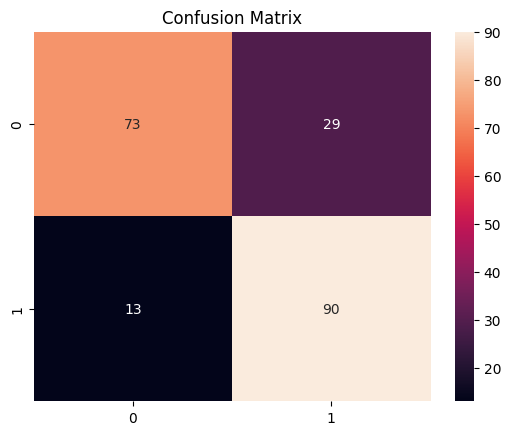

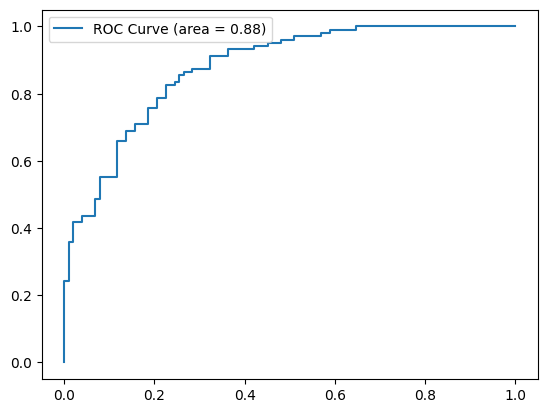

In [ ]:
# Confusion Matrix Plot
sns.heatmap(confusion_matrix(Y_test, Y_pred), annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(Y_test, model.predict_proba(X_test)[:,1])
plt.plot(fpr, tpr, label='ROC Curve (area = %0.2f)' % auc(fpr, tpr))
plt.legend()
plt.show()


In [ ]:
importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.coef_[0]})
print(importance.sort_values(by='Importance', ascending=False))


     Feature  Importance
2         cp    0.847057
10     slope    0.535876
6    restecg    0.262391
7    thalach    0.028880
0        age    0.000642
4       chol   -0.008867
3   trestbps   -0.018159
5        fbs   -0.164529
9    oldpeak   -0.679894
11        ca   -0.814054
8      exang   -0.835868
12      thal   -1.072174
1        sex   -1.714708


In [ ]:
from google.colab import files
import pandas as pd

df.to_csv('my_dataset.csv', index=False)

files.download('my_dataset.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>